In [1]:
import models.model as modelgen
from configs import config
import torch
import torch.nn as nn
import utils.log as log
import json
import numpy as np

In [2]:
def get_dct_matrix(N):
    dct_m = np.eye(N)
    for k in np.arange(N):
        for i in np.arange(N):
            w = np.sqrt(2 / N)
            if k == 0:
                w = np.sqrt(1 / N)
            dct_m[k, i] = w * np.cos(np.pi * (i + 1 / 2) * k / N)
    idct_m = np.linalg.inv(dct_m)
    return dct_m, idct_m

dct_m, idct_m = get_dct_matrix(4)

In [3]:
a = torch.arange(32*32*60*3, dtype=torch.double) - 5
B = a.reshape((32, 32, 60*3))
dct_m, idct_m = get_dct_matrix(32)
dct_m = torch.tensor(dct_m).unsqueeze(0)
idct_m = torch.tensor(idct_m).unsqueeze(0)
torch.matmul(dct_m, B).shape

torch.Size([32, 32, 180])

In [4]:
torch.matmul(idct_m, torch.matmul(dct_m, B)).shape

torch.Size([32, 32, 180])

In [5]:
from torch import linalg as LA

a = torch.arange(32*32*60*3, dtype=torch.float) - 5
B = a.reshape((32, 32, 60*3))
c = torch.arange(32*32*60*3, dtype=torch.float)
D = c.reshape((32, 32, 60*3))
loss = torch.mean(LA.vector_norm(B-D, 2, -1))
LA.vector_norm(B-D, 2, -1).shape
loss

tensor(67.0820)

In [6]:
a = torch.arange(32*32*60*3, dtype=torch.float) - 5
B = a.reshape((-1, 60*3))
c = torch.arange(32*32*60*3, dtype=torch.float)
D = c.reshape((-1, 60*3))
loss = torch.mean(LA.vector_norm(B-D, 2, 1))
LA.vector_norm(B-D, 2, 1).shape
loss

tensor(67.0820)

In [7]:
def gen_velocity(m):
    dm = m[:, 1:] - m[:, :-1]
    return dm
dloss = LA.vector_norm(gen_velocity(B)-gen_velocity(D), 2, -1)
dloss.shape

torch.Size([1024])

In [8]:
cfgs = config.Configurations('./configs/LSFB/siMLPe/depth_medium.yaml')

logger = log.make_logger('./logs/testing/', "test", None)
logger.info("Run name : {run_name}".format(run_name='test'))
for k, v in cfgs.super_cfgs.items():
    logger.info("cfgs." + k + " =")
    logger.info(json.dumps(vars(v), indent=2))

[INFO] 2024-06-07 11:19:30 > Run name : test
[INFO] 2024-06-07 11:19:30 > cfgs.DATA =
[INFO] 2024-06-07 11:19:30 > {
  "name": "LSFB",
  "input_size": [
    16,
    60,
    3
  ],
  "num_classes": 610,
  "min_samples": 20,
  "max_len": 32,
  "target_len": 16,
  "oversample": true,
  "poses": [
    [
      "pose",
      [
        12,
        14,
        16,
        11,
        13,
        15
      ]
    ],
    [
      "right_hand",
      "all"
    ],
    [
      "left_hand",
      "all"
    ],
    [
      "face",
      [
        61,
        0,
        291,
        17,
        33,
        159,
        133,
        145,
        263,
        386,
        362,
        374
      ]
    ]
  ],
  "num_keypoints": 60,
  "flip_p": 0.0,
  "scale": 0.0,
  "random_crop": false,
  "drop_frame": 0.0,
  "drop_keypoint": 0.0,
  "block_size": 5,
  "rot": 0.0
}
[INFO] 2024-06-07 11:19:30 > cfgs.MODEL =
[INFO] 2024-06-07 11:19:30 > {
  "backbone": "siMLPe",
  "apply_sn": false,
  "act_fn": "ReLU",
  "featu

In [9]:
rank = torch.cuda.current_device()
model = modelgen.load_model(DATA=cfgs.DATA,
                                MODEL=cfgs.MODEL,
                                MODULES=cfgs.MODULES,
                                RUN=cfgs.RUN,
                                device=rank,
                                logger=logger)

[INFO] 2024-06-07 11:19:30 > Build the model.
[INFO] 2024-06-07 11:19:30 > Modules are located on './src/models.siMLPe'.
[INFO] 2024-06-07 11:19:30 > Number of parameters: 67688
[INFO] 2024-06-07 11:19:30 > Model(
  (arr0): Rearrange('b n d -> b d n')
  (arr1): Rearrange('b d n -> b n d')
  (motion_mlp): TransMLP(
    (mlps): Sequential(
      (0): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=16, out_features=16, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (1): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=16, out_features=16, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (2): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=16, out_features=16, bias=True)
        )
        (norm0): SLayerNorm()
      )
      (3): MLPblock(
        (fc0): Temporal_FC(
          (fc): Linear(in_features=16, out_features=16, bias=True)
        )
        (norm0): SLayerNorm()
      )
    

In [10]:
from torchinfo import summary

batch_size = 32
summary(model, input_size=(batch_size, 16,60*3), depth=1)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [32, 16, 180]             --
├─Linear: 1-1                            [32, 16, 180]             32,580
├─Rearrange: 1-2                         [32, 180, 16]             --
├─TransMLP: 1-3                          [32, 180, 16]             2,528
├─Rearrange: 1-4                         [32, 16, 180]             --
├─Linear: 1-5                            [32, 16, 180]             32,580
Total params: 67,688
Trainable params: 67,688
Non-trainable params: 0
Total mult-adds (M): 2.12
Input size (MB): 0.37
Forward/backward pass size (MB): 7.37
Params size (MB): 0.27
Estimated Total Size (MB): 8.01

In [11]:
# Generate a random input tensor
input_tensor = torch.randn(32, cfgs.DATA.input_size[0], cfgs.DATA.input_size[1]*cfgs.DATA.input_size[2]).to(rank)

# Pass the input tensor through the model
output_tensor = model(input_tensor)

# Print the output tensor
print(output_tensor.shape)

torch.Size([32, 16, 180])


In [12]:
from data.data_util import Dataset_, train_val_dataset, OversamplingWrapper
import utils.misc as misc

data_name = "LSFB"
data_dir = "/mnt/sda2/datasets/isolated-cont-sl/LSFB/"
poses = [["pose",[12,14,16,11,13,15]],["right_hand","all"],["left_hand","all"], ["face",[61,0,291,17,33,159,133,145,263,386,362,374]]]
dset_used = 1
seed = 42
oversample = True

print("Load {name} train dataset.".format(name=data_name))
train_dataset = Dataset_(data_dir=data_dir,
                            train=True,
                            load_data_in_memory=False,
                            poses=poses,
                            max_len=32,
                            min_samples=20,
                            target_len=16,
                            mode="prediction")
print("Train dataset size: {dataset_size}".format(dataset_size=len(train_dataset)))


Load LSFB train dataset.
Train dataset size: 52350


In [13]:
import torch.utils.benchmark as benchmark

input = train_dataset[0]
values = torch.reshape(input[0], (1,input[0].shape[0],input[0].shape[1])).to(rank)

def stepmodel(input):
    with torch.autocast("cuda"):
        # Pass the input tensor through the model
        output_tensor = model(input.float())
    return output_tensor

t0 = benchmark.Timer(
    stmt='stepmodel(x)',
    setup='from __main__ import stepmodel',
    globals={'x': values},
    num_threads=4)

print(t0.timeit(100))

stepmodel(x)
setup: from __main__ import stepmodel
  1.55 ms
  1 measurement, 100 runs , 4 threads


In [22]:
train_dataset.data['sign'].value_counts().max()

sign,counts
i64,u32
943,1744


In [23]:
train_dataset.data['sign'].value_counts().min()

sign,counts
i64,u32
0,20


In [15]:
def i_normalize(data, pose):
    mean = {
        'pose': [0.0011, 0.1365, 0.0693],
        'right_hand': [-0.0325,  0.1191,  0.0000],
        'left_hand': [0.0251, 0.1365, 0.0000],
        'face': [-0.0024, -0.0086,  0.1384]
    }
    std = {
        'pose': [0.0184, 0.1365, 0.0692],
        'right_hand': [0.0111, 0.0222, 42],
        'left_hand': [0.0105, 0.0198, 42],
        'face': [0.0046, 0.0086, 0.0040]
    }

    mean = np.array(mean[pose])
    std = np.array(std[pose])

    mean = mean[None, None, :]
    std = std[None, None, :]

    # Normalize the data
    normalized_data = data * std + mean

    return normalized_data

In [16]:
input = torch.unflatten(train_dataset[15][0], 1, (60, 3))
body_kp = i_normalize(input[:,:6,:], 'pose')
rhand_kp = i_normalize(input[:,6:(6+21),:], 'right_hand')
lhand_kp = i_normalize(input[:,(6+21):(6+21+21),:], 'left_hand')
face_kp = i_normalize(input[:,(6+21+21):,:], 'face')
face_kp.shape

torch.Size([16, 12, 3])

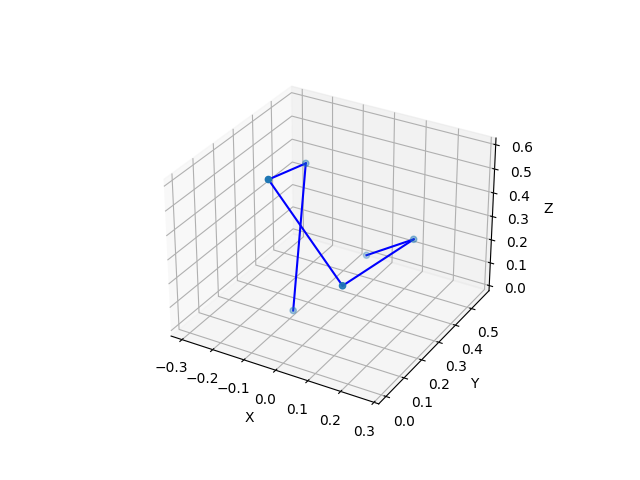

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (0, 3), (3, 4), (4, 5)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 0), 
                    (4, 5), (5, 6), (6, 7), (7, 4),
                    (8, 9), (9, 10), (10, 11), (11, 8)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]

def plot_keypoints(xyz_keypoints, connections):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    xs = xyz_keypoints[:, 0]
    ys = xyz_keypoints[:, 1]
    zs = xyz_keypoints[:, 2]

    ax.scatter(xs, ys, zs)

    for connection in connections:
        start = connection[0]
        end = connection[1]

        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')

    # Set aspect ratio
    max_range = np.array([xs.max()-xs.min(), ys.max()-ys.min(), zs.max()-zs.min()]).max() / 2.0
    mid_x = (xs.max()+xs.min()) * 0.5
    mid_y = (ys.max()+ys.min()) * 0.5
    mid_z = (zs.max()+zs.min()) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)

    plt.show()
plot_keypoints(body_kp[0], POSE_CONNECTIONS)

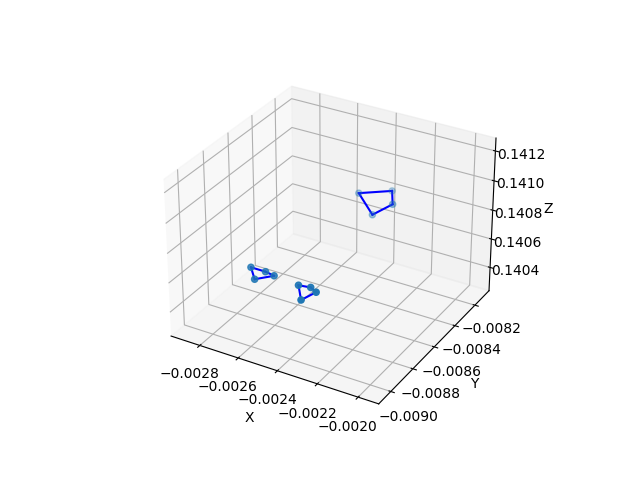

In [25]:
plot_keypoints(i_normalize(face_kp, 'face')[0], FACE_CONNECTIONS)

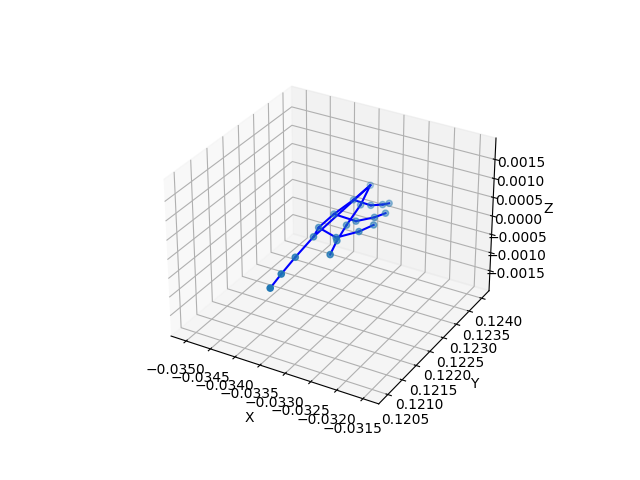

In [26]:
plot_keypoints(i_normalize(rhand_kp, 'right_hand')[0], HAND_CONNECTIONS)

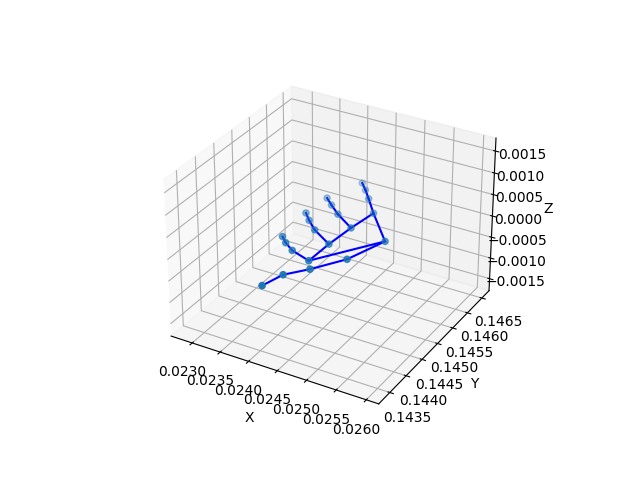

In [27]:
plot_keypoints(i_normalize(lhand_kp, 'left_hand')[0], HAND_CONNECTIONS)

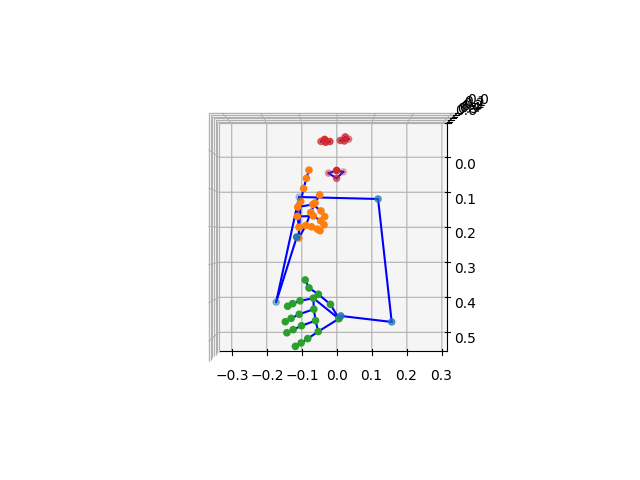

In [28]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (0, 3), (3, 4), (4, 5)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 0), 
                    (4, 5), (5, 6), (6, 7), (7, 4),
                    (8, 9), (9, 10), (10, 11), (11, 8)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]

def plot_all_keypoints(pose_keypoints, rhand_keypoints, lhand_keypoints, face_keypoints):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    xs_max, xs_min, ys_max, ys_min, zs_max, zs_min = np.empty(4), np.empty(4), np.empty(4), np.empty(4), np.empty(4), np.empty(4)

    xs_max[0], xs_min[0], ys_max[0], ys_min[0], zs_max[0], zs_min[0] = create_axis(ax, pose_keypoints, POSE_CONNECTIONS)
    xs_max[1], xs_min[1], ys_max[1], ys_min[1], zs_max[1], zs_min[1] = create_axis(ax, rhand_keypoints, HAND_CONNECTIONS)
    xs_max[2], xs_min[2], ys_max[2], ys_min[2], zs_max[2], zs_min[2] = create_axis(ax, lhand_keypoints, HAND_CONNECTIONS)
    xs_max[3], xs_min[3], ys_max[3], ys_min[3], zs_max[3], zs_min[3] = create_axis(ax, face_keypoints, FACE_CONNECTIONS)

    xs_max = max(xs_max)
    ys_max = max(ys_max)
    zs_max = max(zs_max)
    xs_min = min(xs_min)
    ys_min = min(ys_min)
    zs_min = min(zs_min)

    # Set aspect ratio
    max_range = np.array([xs_max-xs_min, ys_max-ys_min, zs_max-zs_min]).max() / 2.0
    mid_x = (xs_max+xs_min) * 0.5
    mid_y = (ys_max+ys_min) * 0.5
    mid_z = (zs_max+zs_min) * 0.5
    ax.set_xlim(mid_x - max_range, mid_x + max_range)
    ax.set_ylim(mid_y - max_range, mid_y + max_range)
    ax.set_zlim(mid_z - max_range, mid_z + max_range)
    ax.view_init(-90, -90)

    plt.show()

def create_axis(ax, xyz_keypoints, connections):

    xs = xyz_keypoints[:, 0]
    ys = xyz_keypoints[:, 1]
    zs = xyz_keypoints[:, 2]

    ax.scatter(xs, ys, zs)

    for connection in connections:
        start = connection[0]
        end = connection[1]

        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')
    
    return xs.max(), xs.min(), ys.max(), ys.min(), zs.max(), zs.min()

plot_all_keypoints(body_kp[0], rhand_kp[0], lhand_kp[0], face_kp[0])

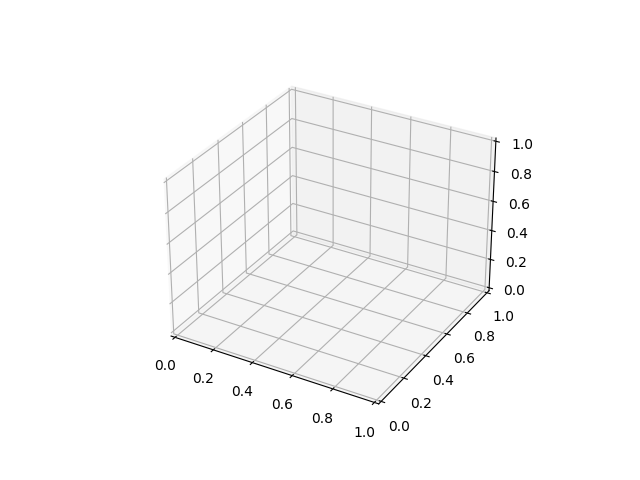

In [29]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (0, 3), (3, 4), (4, 5)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 0), 
                    (4, 5), (5, 6), (6, 7), (7, 4),
                    (8, 9), (9, 10), (10, 11), (11, 8)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]

def animate_keypoints(xyz_keypoints, connections):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    xss = xyz_keypoints[:, :, 0]
    yss = xyz_keypoints[:, :, 1]
    zss = xyz_keypoints[:, :, 2]

    def animate(i):
        ax.cla()   
        xs = xss[i]
        ys = yss[i]
        zs = zss[i]
        ax.scatter(xs, ys, zs)

        for connection in connections:
            start = connection[0]
            end = connection[1]

            ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')

        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')

        # Set aspect ratio
        max_range = np.array([xss[0].max()-xss[0].min(), yss[0].max()-yss[0].min(), zss[0].max()-zss[0].min()]).max() / 2.0
        mid_x = (xss[0].max()+xss[0].min()) * 0.5
        mid_y = (yss[0].max()+yss[0].min()) * 0.5
        mid_z = (zss[0].max()+zss[0].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        ax.view_init(-70, -90)

    
    ani = animation.FuncAnimation(fig, animate, repeat=False,
                                        frames=len(xyz_keypoints) - 1, interval=50)

    plt.show()

anim = animate_keypoints(i_normalize(body_kp, 'pose'), POSE_CONNECTIONS)

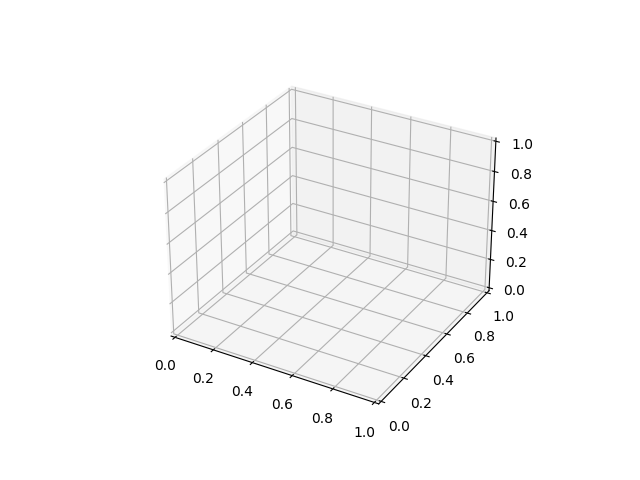

In [30]:
anim = animate_keypoints(i_normalize(face_kp, 'face'), FACE_CONNECTIONS)

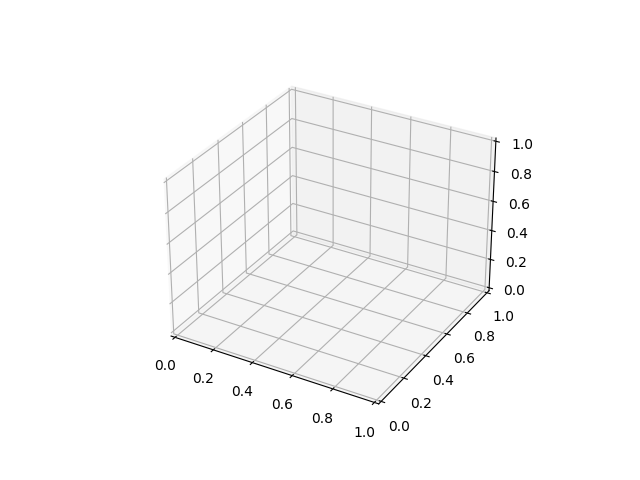

In [31]:
anim = animate_keypoints(i_normalize(rhand_kp, 'right_hand'), HAND_CONNECTIONS)

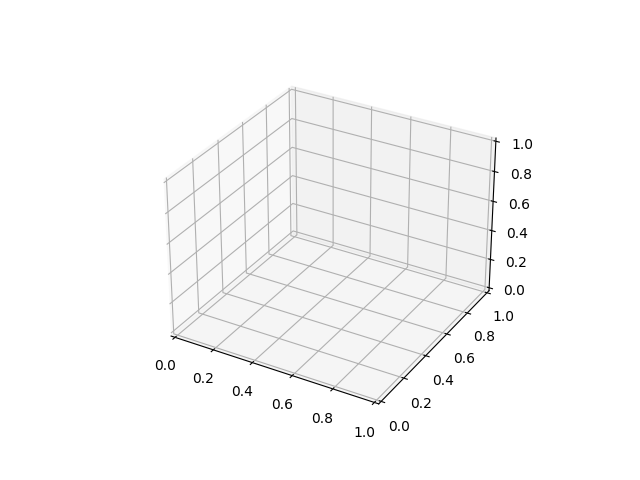

In [32]:
anim = animate_keypoints(i_normalize(lhand_kp, 'left_hand'), HAND_CONNECTIONS)

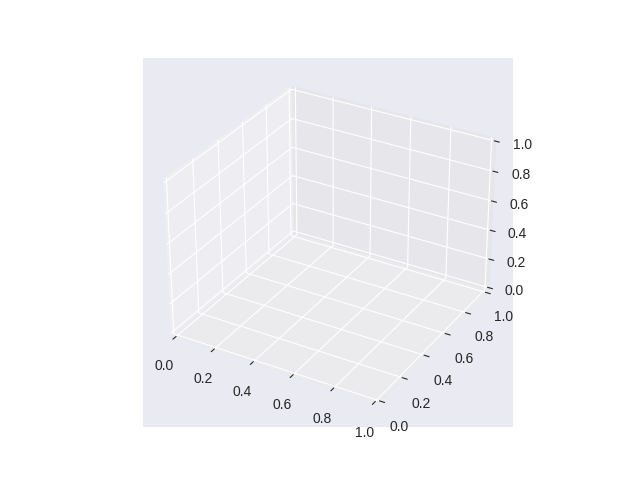

In [33]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.animation as animation
import numpy as np
%matplotlib ipympl

# MediaPipe pose landmarks connection (in their order)
POSE_CONNECTIONS = [(0, 1), (1, 2), (0, 3), (3, 4), (4, 5)]
FACE_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 0), 
                    (4, 5), (5, 6), (6, 7), (7, 4),
                    (8, 9), (9, 10), (10, 11), (11, 8)]
HAND_CONNECTIONS = [(0, 1), (1, 2), (2, 3), (3, 4), (0, 5), (0, 17), (5, 9), (9, 13), (13, 17), (5, 6), (6, 7), (7, 8), (9, 10), (10, 11), (11, 12), (13, 14), (14, 15), (15, 16), (17, 18), (18, 19), (19, 20)]


def animate_all_keypoints(pose_keypoints, rhand_keypoints, lhand_keypoints, face_keypoints):
    fig = plt.figure()
    plt.style.use('seaborn-darkgrid')
    ax = fig.add_subplot(111, projection='3d')

    def animate(i):
        ax.cla()

        xs_max, xs_min, ys_max, ys_min, zs_max, zs_min = np.empty(4), np.empty(4), np.empty(4), np.empty(4), np.empty(4), np.empty(4)
        xs_max[0], xs_min[0], ys_max[0], ys_min[0], zs_max[0], zs_min[0] = create_axis(ax, pose_keypoints, i, POSE_CONNECTIONS)
        xs_max[1], xs_min[1], ys_max[1], ys_min[1], zs_max[1], zs_min[1] = create_axis(ax, rhand_keypoints, i, HAND_CONNECTIONS)
        xs_max[2], xs_min[2], ys_max[2], ys_min[2], zs_max[2], zs_min[2] = create_axis(ax, lhand_keypoints, i, HAND_CONNECTIONS)
        xs_max[3], xs_min[3], ys_max[3], ys_min[3], zs_max[3], zs_min[3] = create_axis(ax, face_keypoints, i, FACE_CONNECTIONS)

        xs_max = max(xs_max)
        ys_max = max(ys_max)
        zs_max = max(zs_max)
        xs_min = min(xs_min)
        ys_min = min(ys_min)
        zs_min = min(zs_min)

        # Set aspect ratio
        max_range = np.array([xs_max-xs_min, ys_max-ys_min, zs_max-zs_min]).max() / 2.0
        mid_x = (xs_max+xs_min) * 0.5
        mid_y = (ys_max+ys_min) * 0.5
        mid_z = (zs_max+zs_min) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

        ax.view_init(-90, -90)

    
    ani = animation.FuncAnimation(fig, animate, repeat=False,
                                        frames=len(pose_keypoints) - 1, interval=50)

    plt.show()
    return ani

def create_axis(ax, xyz_keypoints, i, connections):
    xs = xyz_keypoints[i, :, 0]
    ys = xyz_keypoints[i, :, 1]
    zs = xyz_keypoints[i, :, 2]
    ax.scatter(xs, ys, zs, s=5)

    for connection in connections:
        start = connection[0]
        end = connection[1]

        ax.plot([xs[start], xs[end]], [ys[start], ys[end]], [zs[start], zs[end]], 'blue')

    return xyz_keypoints[0, :, 0].max(), xyz_keypoints[0, :, 0].min(), xyz_keypoints[0, :, 1].max(), xyz_keypoints[0, :, 1].min(), xyz_keypoints[0, :, 2].max(), xyz_keypoints[0, :, 2].min()

anim = animate_all_keypoints(body_kp, rhand_kp, lhand_kp, face_kp)

In [34]:
save_path = './example.gif'

writer = animation.PillowWriter(fps=15,
                                metadata=dict(artist='Me'),
                                bitrate=1800)
anim.save(save_path, writer=writer, dpi=200)